# **Simple Linear Regression**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def estimate_coef(x, y):
#   # number of observations/points
  n = np.size(x)

#   # mean of x and y vector
  m_x = np.mean(x)
  m_y = np.mean(y)

#   # calculating cross-deviation and deviation about x
  SS_xy = np.sum(y*x) - n*m_y*m_x
  SS_xx = np.sum(x*x) - n*m_x*m_x

#   # calculating regression coefficients
  b_1 = SS_xy / SS_xx
  b_0 = m_y - b_1*m_x

  return (b_0, b_1)

In [ ]:
def plot_regression_line(x, y, b):
#   # plotting the actual points as scatter plot
  plt.scatter(x, y, color = "m",
  marker = "o", s = 30)

#   # predicted response vector
  y_pred = b[0] + b[1]*x

#   # plotting the regression line
  plt.plot(x, y_pred, color = "g")

#   # putting labels
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()

b0 = 1.2363636363636363
b1 = 1.1696969696969697


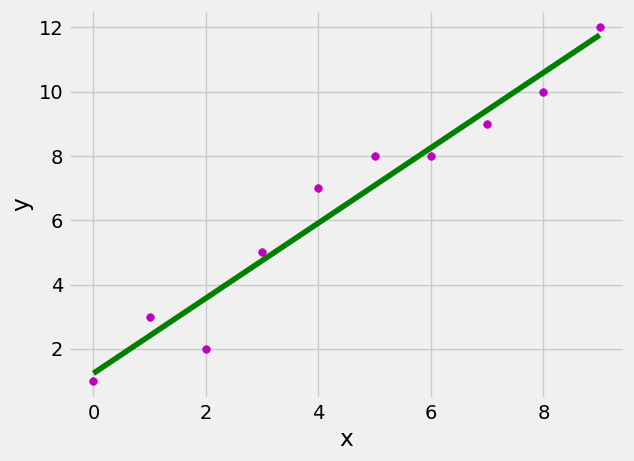

In [ ]:

  # observations / data
  x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
  y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])

  # estimating coefficients
  b = estimate_coef(x, y)
  # print("Estimated coefficients:\nb_0 = {}\nb_1 = {}".format(b[0], b[1]))
  print("b0 =",b[0])
  print("b1 =",b[1])
  plot_regression_line(x, y, b)


# **Multiple Linear Regression**

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics
import pandas as pd

In [ ]:
data_url = "https://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+",skiprows=22, header=None)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2362923149.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+",skiprows=22, header=None)


In [ ]:
X = np.hstack([raw_df.values[::2, :],raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

In [ ]:
X_train, X_test,\
  y_train, y_test = train_test_split(X, y,
  test_size=0.4,
  random_state=1)

In [ ]:
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
# regression coefficients
print('Coefficients: ', reg.coef_)

# variance score: 1 means perfect prediction
print('Variance score: {}'.format(reg.score(X_test, y_test)))

Coefficients:  [-8.95714048e-02  6.73132853e-02  5.04649248e-02  2.18579583e+00
 -1.72053975e+01  3.63606995e+00  2.05579939e-03 -1.36602886e+00
  2.89576718e-01 -1.22700072e-02 -8.34881849e-01  9.40360790e-03
 -5.04008320e-01]
Variance score: 0.720905667266174


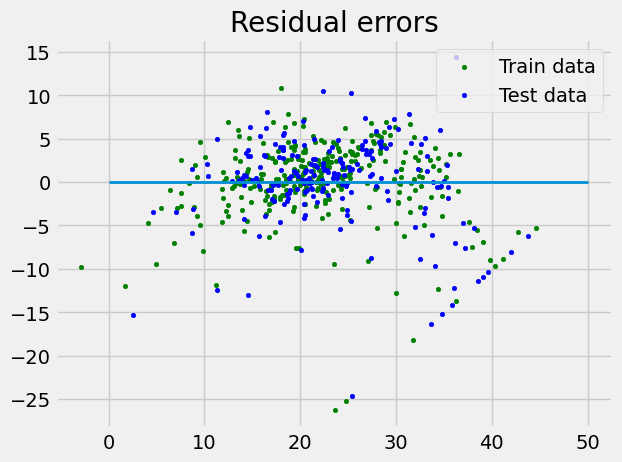

In [ ]:
# plot for residual error

# setting plot style
plt.style.use('fivethirtyeight')

# plotting residual errors in training data
plt.scatter(reg.predict(X_train),
            reg.predict(X_train) - y_train,
            color="green", s=10,
            label='Train data')

# plotting residual errors in test data
plt.scatter(reg.predict(X_test),
            reg.predict(X_test) - y_test,
            color="blue", s=10,
            label='Test data')

# plotting line for zero residual error
plt.hlines(y=0, xmin=0, xmax=50, linewidth=2)

# plotting legend
plt.legend(loc='upper right')

# plot title
plt.title("Residual errors")

# method call for showing the plot
plt.show()

# **Polynomial Linear Regression**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

df = pd.read_csv('Position_Salaries.csv')

X = df.iloc[:,1:2].values
y = df.iloc[:,2].values


In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X,y)

LinearRegression()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg2=PolynomialFeatures(degree=2)
X_poly=poly_reg2.fit_transform(X)
lin_reg_2=LinearRegression()
lin_reg_2.fit(X_poly,y)

poly_reg3=PolynomialFeatures(degree=3)
X_poly3=poly_reg3.fit_transform(X)
lin_reg_3=LinearRegression()
lin_reg_3.fit(X_poly3,y)

LinearRegression()

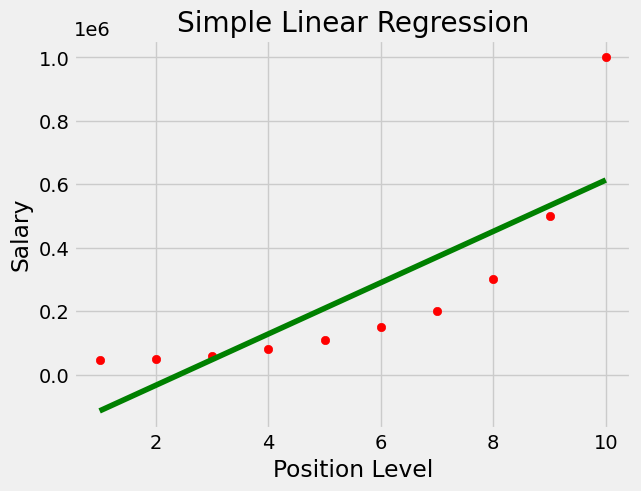

In [ ]:
plt.scatter(X,y,color='red')
plt.plot(X,lin_reg.predict(X),color='green')
plt.title('Simple Linear Regression')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

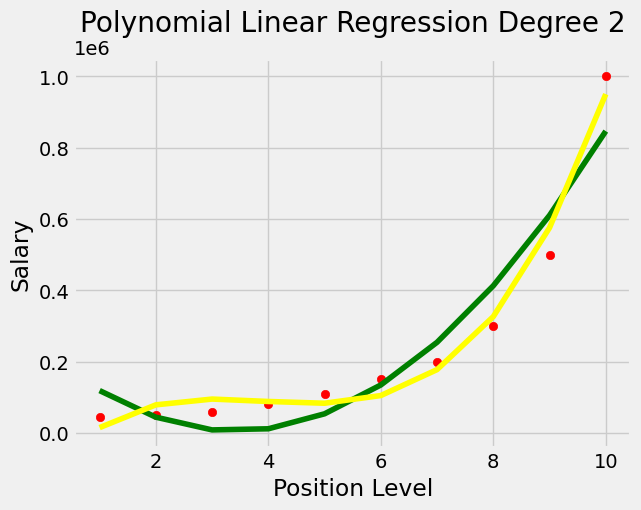

In [ ]:
plt.style.use('fivethirtyeight')
plt.scatter(X,y,color='red')
plt.plot(X,lin_reg_2.predict(poly_reg2.fit_transform(X)),color='green')
plt.plot(X,lin_reg_3.predict(poly_reg3.fit_transform(X)),color='yellow')
plt.title('Polynomial Linear Regression Degree 2')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

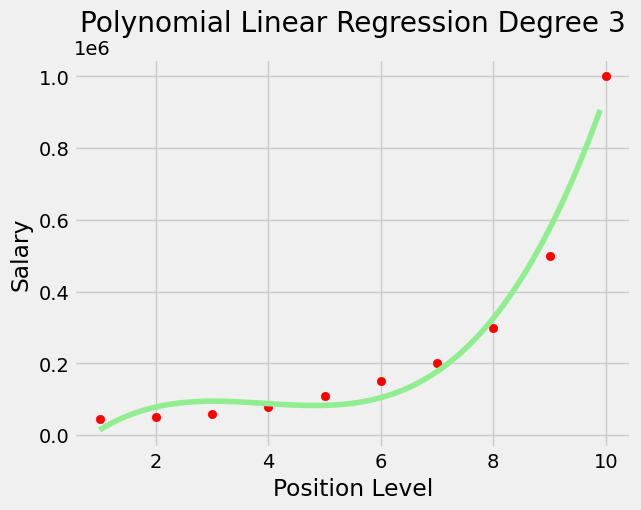

In [ ]:
plt.style.use('fivethirtyeight')
X_grid=np.arange(min(X),max(X),0.1) # This will give us a vector.We will have to convert this into a matrix
X_grid=X_grid.reshape((len(X_grid),1))
plt.scatter(X,y,color='red')
plt.plot(X_grid,lin_reg_3.predict(poly_reg3.fit_transform(X_grid)),color='lightgreen')

#plt.plot(X,lin_reg_3.predict(poly_reg3.fit_transform(X)),color='green')
plt.title('Polynomial Linear Regression Degree 3')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()